# Script to connect with copernicus API, calculate snowcover maps and download all available maps as .tif files for aspecific AOI and time range

In [ ]:
# Utilities
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
import matplotlib.patches as mpatches

import pandas as pd
import getpass
import numpy as np
from typing import Any, Optional, Tuple
from datetime import datetime, timedelta
import os
import shutil
from pathlib import Path
import xarray as xr
import rioxarray as rxr 
import re
from shutil import copy2

from sentinelhub import (SHConfig, DataCollection, SentinelHubCatalog, SentinelHubRequest, SentinelHubStatistical, BBox,
    bbox_to_dimensions, CRS, MimeType, Geometry, SentinelHubDownloadClient)

## set up connection to API

In [ ]:
# Configuration
# Set up your Sentinel Hub configuration if already done and saved, else activate next code box
config = SHConfig("MO_v2")

if not config.sh_client_id or not config.sh_client_secret:
    print("Warning! To use Process API, please provide the credentials (OAuth client ID and client secret).")
else: print("Connection successful")

Connection successful


In [ ]:
# # Set up your Sentinel Hub configuration if not already done
# config = SHConfig()

# # Sentinel account info
# config.instance_id = "607e0864-6586-4c05-a03e-6b32dbdf464d"  # Replace with your Sentinel Hub instance ID                                           fc2993a7-a8a9-4df5-8654-a32bd1472bda
# config.sh_client_id = "sh-39df67cf-aaa5-446c-9e13-746c7492030a"  # Replace with your client ID
# config.sh_client_secret = "2WcV5QxAAJgMeXa691D8QeGp38kYzVOa"  # Replace with your client secret
# config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
# config.sh_base_url = "https://sh.dataspace.copernicus.eu"

# config.save("MO_v2")

# # test connection
# config = SHConfig()

# if not config.sh_client_id or not config.sh_client_secret:
#     print("Warning! To use Process API, please provide the credentials (OAuth client ID and client secret).")
# else: print("Connection successful")

## define the variables!

### coordinates examples
test 1: 11.669884, 47.429597, 11.834679, 47.484555                 (wgs84 - 4326) Achensee region small area 

test 2: 697989.4242, 5259657.0058, 707033.7375, 5268705.5889       (utm 32N - 32632) Achensee region small area

Achensee full extent: 688675, 5250625, 710875, 5274625

Kuehtai full extent: 645975, 5204025, 673175, 5234725

Kaunertal full extent: 618775, 5187025, 646775, 5213325

define your own bbox coordinates here: http://bboxfinder.com

In [ ]:
# define variables
coords = (618775, 5187025, 646775, 5213325)    # Coordinates of the box in  wgs84 (http://bboxfinder.com)
epsg = 32632                                                                # define the epsg code of the coordinates
resolution = 20                                                             # resolution in meters
time_interval = "2022-10-01", "2023-08-31"                                  # time interval: for this time interval all available images are being downloaded
output_folder = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kaunertal_2022-2023"                                        # define the location of the output folder
cloud_mask = 50                                                           # % of the max. cloud cover for the images that should be included in the search (clouds are masked and set to na later)

In [ ]:
aoi_bbox = BBox(bbox=coords, crs=CRS(epsg))   # define bbox
aoi_size = bbox_to_dimensions(aoi_bbox, resolution=resolution)   # define size

print(f"Image shape at {resolution} m resolution: {aoi_size} pixels")

Image shape at 20 m resolution: (1400, 1315) pixels


In [ ]:
# Make sure your Sentinel Hub credentials are set correctly before running this cell!
# If you haven't already, uncomment and run the credential setup cell above.

# search in catalog for all available images with the defined variables
catalog = SentinelHubCatalog(config=config)

search_iterator = catalog.search(       
    DataCollection.SENTINEL2_L2A,
    bbox=aoi_bbox,
    time=time_interval,
    fields={"include": ["id", "properties.datetime"], "exclude": []},
    filter=f"eo:cloud_cover < {cloud_mask}"
)

results = list(search_iterator)
print("Total number of results:", len(results))

# Create a list of unique days in time_interval
date_list = list({result["properties"]["datetime"][:10] for result in results})
date_list.sort()  # Optional: Sort dates chronologically
# Convert to a list of datetime objects
datetime_list = [datetime.strptime(date, '%Y-%m-%d') for date in date_list]
print("Total number of available days = ", len(datetime_list))
datetime_list

Total number of results: 131
Total number of available days =  67


[datetime.datetime(2023, 10, 3, 0, 0),
 datetime.datetime(2023, 10, 8, 0, 0),
 datetime.datetime(2023, 10, 10, 0, 0),
 datetime.datetime(2023, 10, 13, 0, 0),
 datetime.datetime(2023, 10, 15, 0, 0),
 datetime.datetime(2023, 10, 25, 0, 0),
 datetime.datetime(2023, 10, 28, 0, 0),
 datetime.datetime(2023, 11, 4, 0, 0),
 datetime.datetime(2023, 11, 17, 0, 0),
 datetime.datetime(2023, 11, 22, 0, 0),
 datetime.datetime(2023, 11, 24, 0, 0),
 datetime.datetime(2023, 11, 27, 0, 0),
 datetime.datetime(2023, 11, 29, 0, 0),
 datetime.datetime(2023, 12, 7, 0, 0),
 datetime.datetime(2023, 12, 9, 0, 0),
 datetime.datetime(2023, 12, 14, 0, 0),
 datetime.datetime(2023, 12, 17, 0, 0),
 datetime.datetime(2023, 12, 19, 0, 0),
 datetime.datetime(2023, 12, 24, 0, 0),
 datetime.datetime(2023, 12, 27, 0, 0),
 datetime.datetime(2024, 1, 3, 0, 0),
 datetime.datetime(2024, 1, 11, 0, 0),
 datetime.datetime(2024, 1, 13, 0, 0),
 datetime.datetime(2024, 1, 16, 0, 0),
 datetime.datetime(2024, 1, 21, 0, 0),
 datetime.d

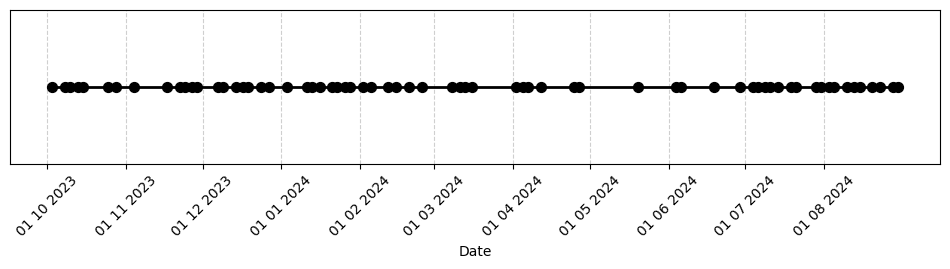

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 2))

# Plot the horizontal timeline
ax.hlines(y=1, xmin=min(datetime_list), xmax=max(datetime_list), color="black", linewidth=2)

# Plot event points
ax.scatter(datetime_list, [1] * len(datetime_list), color="black", s=50, label="Events", zorder=3)

# Remove y-axis
ax.yaxis.set_visible(False)

from dateutil.relativedelta import relativedelta

# Generate all months between min and max date
start = datetime_list[0].replace(day=1)
end = datetime_list[-1].replace(day=1)
month_ticks = []
current = start
while current <= end:
    month_ticks.append(current)
    current += relativedelta(months=1)

ax.set_xticks(month_ticks)
ax.set_xticklabels([dt.strftime("%d %m %Y") for dt in month_ticks], rotation=45)

# Formatting
ax.set_xlabel("Date")
ax.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()


In [ ]:
eval_fsc_scl_mask = """
//VERSION=3
function setup() {
  return {
    input: ["B03", "B11", "SCL"],
    output: { bands: 1, sampleType: "FLOAT32" }
  };
}

function evaluatePixel(sample) {
  let ndsi = (sample.B03 - sample.B11) / (sample.B03 + sample.B11);
  let image_mask = sample.SCL;

  // Mask values: adjust as needed
  let mask_values = [1,6,8,9];

  // FSC thresholds
  let ndsi_min = 0.1;
  let ndsi_max = 0.6;

  // Calculate FSC
  let fsc = 0.0;
  if (ndsi <= ndsi_min) {
    fsc = 0.0;
  } else if (ndsi >= ndsi_max) {
    fsc = 1.0;
  } else {
    fsc = (ndsi - ndsi_min) / (ndsi_max - ndsi_min);
  }

  // Mask out unwanted pixels
  let fsc_masked = mask_values.includes(image_mask) ? NaN : fsc;

  return [fsc_masked];
}
"""

In [ ]:
ndsi_images = []
# loop over all available dates found in the catalog for the time series
for current_date in datetime_list:
    # Define the time interval as a string
    time_interval = (current_date.strftime("%Y-%m-%d"), (current_date + timedelta(days=0)).strftime("%Y-%m-%d"))
    print(f"downloading tif for {time_interval[0]}")
    # define request with the time interval
    request_ndsi = SentinelHubRequest(
        data_folder=(f"{output_folder}/{time_interval[0]}"),
        
        evalscript=eval_fsc_scl_mask,   # select eval script
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A.define_from(   # select data collection
                    "s2l2a", service_url=config.sh_base_url
                ),
                time_interval=time_interval,   # define processed time interval
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],   # select output format (TIFF)
        bbox=aoi_bbox,
        size=aoi_size,
        config=config,
    )
    
    # Get and save the data.
    ndsi_imgs = request_ndsi.get_data(save_data=True)   # save_data=True to save data to the output folder!!!
    ndsi_images.extend(ndsi_imgs)

downloading tif for 2023-10-03
downloading tif for 2023-10-08
downloading tif for 2023-10-10
downloading tif for 2023-10-13
downloading tif for 2023-10-15
downloading tif for 2023-10-25
downloading tif for 2023-10-28
downloading tif for 2023-11-04
downloading tif for 2023-11-17
downloading tif for 2023-11-22
downloading tif for 2023-11-24
downloading tif for 2023-11-27
downloading tif for 2023-11-29
downloading tif for 2023-12-07
downloading tif for 2023-12-09
downloading tif for 2023-12-14
downloading tif for 2023-12-17
downloading tif for 2023-12-19
downloading tif for 2023-12-24
downloading tif for 2023-12-27
downloading tif for 2024-01-03
downloading tif for 2024-01-11
downloading tif for 2024-01-13
downloading tif for 2024-01-16
downloading tif for 2024-01-21
downloading tif for 2024-01-23
downloading tif for 2024-01-26
downloading tif for 2024-01-28
downloading tif for 2024-02-02
downloading tif for 2024-02-05
downloading tif for 2024-02-12
downloading tif for 2024-02-15
download

In [ ]:
# Functions
# reorganize folder structure of results

def process_tiff_files(base_path):

    # Define the base path
    base_path = Path(output_folder)
    target_path = base_path # where we want the results after reorganizing

    # List all date folders
    date_folders = [folder for folder in base_path.iterdir() if folder.is_dir()]

    # Iterate over each date folder
    for date_folder in date_folders:
        # Get the path of the nested folder inside the date folder
        nested_folders = [folder for folder in date_folder.iterdir() if folder.is_dir()]
        
        # Check if there is exactly one nested folder
        if len(nested_folders) == 1:
            nested_folder = nested_folders[0]
            
            # Find the response.tif file inside the folder
            tif_files = [file for file in nested_folder.iterdir() if file.is_file() and file.name == "response.tiff"]
            
            # Check if there is exactly one response.tif file
            if len(tif_files) == 1:
                tif_file = tif_files[0]
                
                # Define the new file name and path
                new_file_name = f"ndsi_{date_folder.name}.tiff"
                new_file_path = target_path / new_file_name
                
                # Move and rename the file
                shutil.move(tif_file, new_file_path)
                print(f"Moved and renamed {new_file_path}")
                
                # Delete the date folder
                shutil.rmtree(date_folder)

    print("results have been reorganized. :)")


In [ ]:
# Call the function with the base path. Reorganizes results folder structure!
process_tiff_files(output_folder)

Moved and renamed C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kaunertal_2023-2024\ndsi_2023-10-03.tiff
Moved and renamed C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kaunertal_2023-2024\ndsi_2023-10-08.tiff
Moved and renamed C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kaunertal_2023-2024\ndsi_2023-10-10.tiff
Moved and renamed C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kaunertal_2023-2024\ndsi_2023-10-13.tiff
Moved and renamed C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kaunertal_2023-2024\ndsi_2023-10-15.tiff
Moved and renamed C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kaunertal_2023-2024\ndsi_2023-10-25.tiff
Moved and renamed C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kaunertal_2023-2024\ndsi_2023-10-28.tiff
Moved and renamed C:\Users\Moritz\Documen

## FSC processing done!

## Snow cover calculation

In [ ]:
# Regular expression to match filenames like ndsi_yyyy-mm-dd.tiff
pattern = re.compile(r"ndsi_(\d{4}-\d{2}-\d{2})\.tiff")

# List to store datasets
datasets = []

# Loop through all files in the folder
for file in os.listdir(output_folder):
    match = pattern.match(file)
    if match:
        date_str = match.group(1)  # Extract the date part
        date = pd.to_datetime(date_str).date()  # Convert to date only (no time)
        file_path = os.path.join(output_folder, file)
        dataset = rxr.open_rasterio(file_path)

        # Check if time dimension exists
        if "time" in dataset.dims:
            print(f"{file}: Already has a time dimension.")
        else:
            # Expand the dataset with a new time dimension
            dataset = dataset.expand_dims(time=[pd.Timestamp(date)])
            print(f"Added time dimension to {file}")

        datasets.append(dataset)

Added time dimension to ndsi_2023-10-03.tiff
Added time dimension to ndsi_2023-10-08.tiff
Added time dimension to ndsi_2023-10-10.tiff
Added time dimension to ndsi_2023-10-13.tiff
Added time dimension to ndsi_2023-10-15.tiff
Added time dimension to ndsi_2023-10-25.tiff
Added time dimension to ndsi_2023-10-28.tiff
Added time dimension to ndsi_2023-11-04.tiff
Added time dimension to ndsi_2023-11-17.tiff
Added time dimension to ndsi_2023-11-22.tiff
Added time dimension to ndsi_2023-11-24.tiff
Added time dimension to ndsi_2023-11-27.tiff
Added time dimension to ndsi_2023-11-29.tiff
Added time dimension to ndsi_2023-12-07.tiff
Added time dimension to ndsi_2023-12-09.tiff
Added time dimension to ndsi_2023-12-14.tiff
Added time dimension to ndsi_2023-12-17.tiff
Added time dimension to ndsi_2023-12-19.tiff
Added time dimension to ndsi_2023-12-24.tiff
Added time dimension to ndsi_2023-12-27.tiff
Added time dimension to ndsi_2024-01-03.tiff
Added time dimension to ndsi_2024-01-11.tiff
Added time

In [ ]:
# Merge all datasets along the time dimension
if datasets:
    combined_dataset = xr.concat(datasets, dim="time")
    print("Merged all datasets along the time dimension.")
else:
    print("No valid NDSI TIFF files found.")

combined_dataset.rio.write_nodata(np.nan, inplace=True)
# Print the dataset structure
print(combined_dataset.time.values)


Merged all datasets along the time dimension.
['2023-10-03T00:00:00.000000000' '2023-10-08T00:00:00.000000000'
 '2023-10-10T00:00:00.000000000' '2023-10-13T00:00:00.000000000'
 '2023-10-15T00:00:00.000000000' '2023-10-25T00:00:00.000000000'
 '2023-10-28T00:00:00.000000000' '2023-11-04T00:00:00.000000000'
 '2023-11-17T00:00:00.000000000' '2023-11-22T00:00:00.000000000'
 '2023-11-24T00:00:00.000000000' '2023-11-27T00:00:00.000000000'
 '2023-11-29T00:00:00.000000000' '2023-12-07T00:00:00.000000000'
 '2023-12-09T00:00:00.000000000' '2023-12-14T00:00:00.000000000'
 '2023-12-17T00:00:00.000000000' '2023-12-19T00:00:00.000000000'
 '2023-12-24T00:00:00.000000000' '2023-12-27T00:00:00.000000000'
 '2024-01-03T00:00:00.000000000' '2024-01-11T00:00:00.000000000'
 '2024-01-13T00:00:00.000000000' '2024-01-16T00:00:00.000000000'
 '2024-01-21T00:00:00.000000000' '2024-01-23T00:00:00.000000000'
 '2024-01-26T00:00:00.000000000' '2024-01-28T00:00:00.000000000'
 '2024-02-02T00:00:00.000000000' '2024-02-05

In [ ]:
# Calculate the percentage of NaN values for each image (along the time dimension)
nan_fraction = combined_dataset.isnull().sum(dim=["x", "y"]) / (combined_dataset.sizes["x"] * combined_dataset.sizes["y"])

# Get indices where NaN fraction is less than or equal to 30%
valid_indices = (nan_fraction <= 0.70).values.flatten()

# Select only valid images
combined_dataset = combined_dataset.isel(time=valid_indices)

print(f"Filtered dataset shape: {combined_dataset.shape}")


Filtered dataset shape: (54, 1, 1315, 1400)


C:\Users\Moritz\AppData\Local\Temp\ipykernel_22720\181554527.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis").copy()
C:\Users\Moritz\AppData\Local\Temp\ipykernel_22720\181554527.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 1])


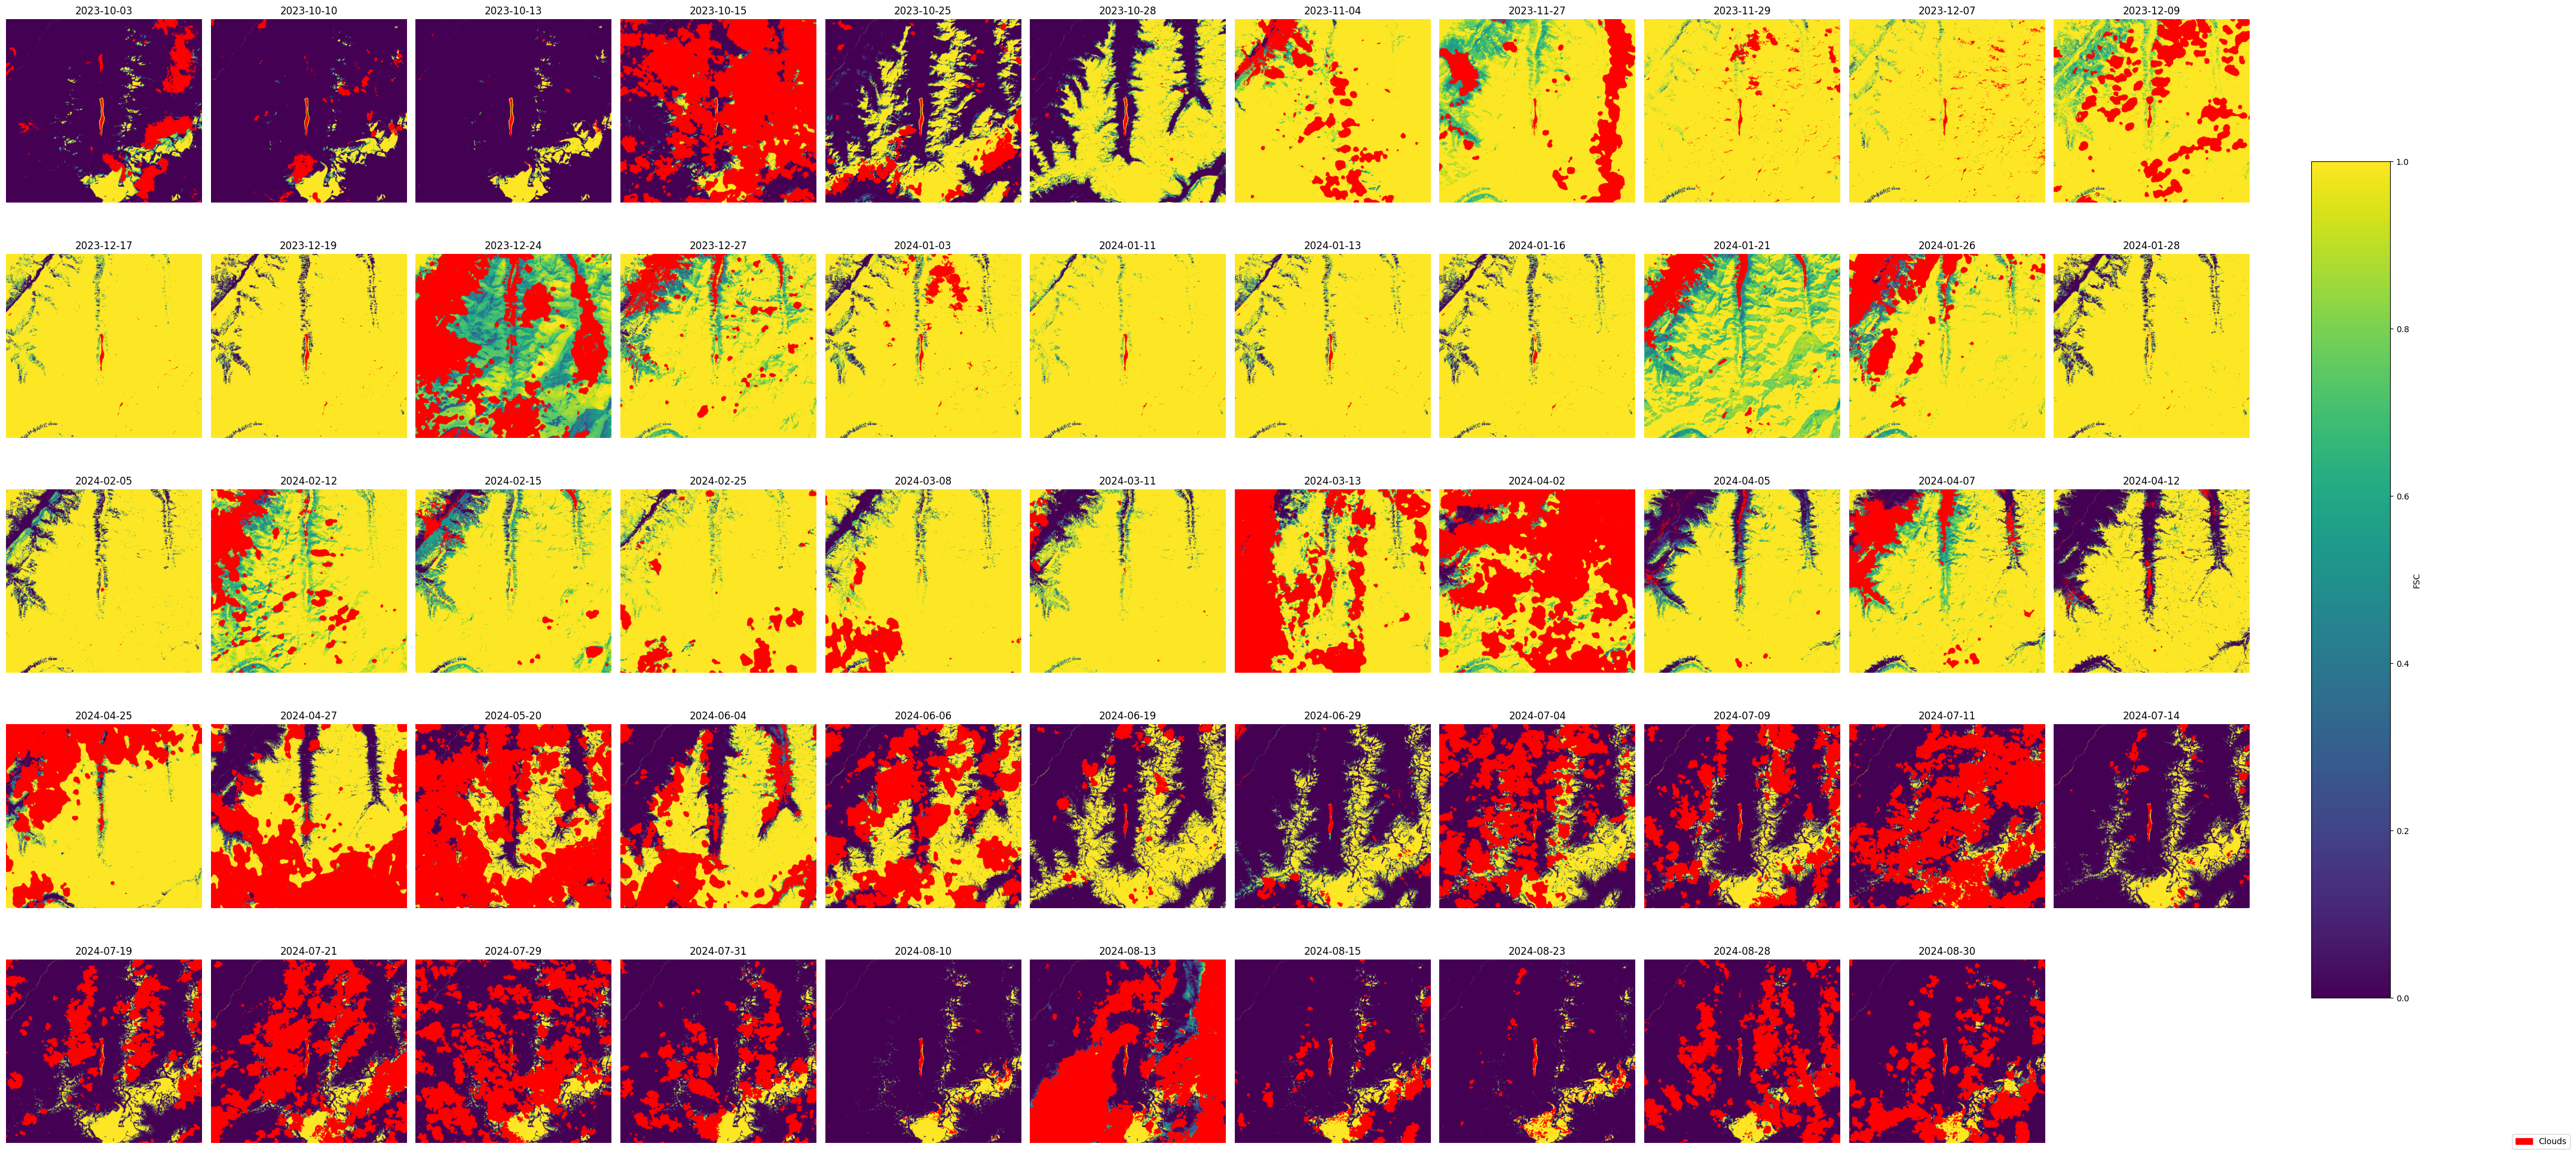

In [ ]:
# Settings
n_images = len(combined_dataset.time)
nrows = 5
ncols = int(np.ceil(n_images / nrows))

# Create a copy of the viridis colormap and set NaN (bad) color to red
cmap = cm.get_cmap("viridis").copy()
cmap.set_bad(color="red")

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))
axes = axes.flatten()

for i in range(n_images):
    ax = axes[i]
    img = np.ma.masked_invalid(combined_dataset[i, 0, :, :])
    im = ax.imshow(img, vmin=0, vmax=1, cmap=cmap)
    ax.set_title(f"{str(combined_dataset.time.values[i])[:10]}")
    ax.axis("off")

# Hide unused subplots
for j in range(n_images, len(axes)):
    axes[j].axis("off")

# Add colorbar and legend to the last axis
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cbar_ax, label="FSC")

# Add custom legend for NaN (red)
red_patch = mpatches.Patch(color='red', label='Clouds')
fig.legend(handles=[red_patch], loc='lower right', bbox_to_anchor=(0.98, 0.02))

plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()

### Now MANUALLY!! select the dates which are copied to the folder "selected"

In [73]:
# Define a list of dates to select

selected_dates = [
    datetime(2023, 10, 13),
    datetime(2023, 10, 28),
    datetime(2023, 2, 5),
    datetime(2024, 3, 11),
    datetime(2024, 4, 12),
    datetime(2024, 5, 20),
    datetime(2024, 6, 19),
    datetime(2024, 6, 29),
    datetime(2024, 7, 9),
    datetime(2024, 7, 14),
    datetime(2024, 8, 10)
]

# Create the output directory if it doesn't exist
selected_dir = os.path.join(output_folder, "selected")
os.makedirs(selected_dir, exist_ok=True)

# Save the selected dates' corresponding TIFF files (if available) to the "selected" directory

# Convert selected_dates to set of strings for easy matching
selected_date_strs = set(dt.strftime("%Y-%m-%d") for dt in selected_dates)

# Loop through all TIFF files in the output folder
for file in os.listdir(output_folder):
    if file.endswith(".tiff") and file.startswith("ndsi_"):
        date_part = file[5:-5]  # Extract date from filename "ndsi_YYYY-MM-DD.tiff"
        if date_part in selected_date_strs:
            src_path = os.path.join(output_folder, file)
            dst_path = os.path.join(selected_dir, file)
            shutil.copy2(src_path, dst_path)
            print(f"Copied {file} to {selected_dir}")

Copied ndsi_2023-10-13.tiff to C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kuehtai_2023-2024\selected
Copied ndsi_2023-10-28.tiff to C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kuehtai_2023-2024\selected
Copied ndsi_2024-03-11.tiff to C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kuehtai_2023-2024\selected
Copied ndsi_2024-04-12.tiff to C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kuehtai_2023-2024\selected
Copied ndsi_2024-05-20.tiff to C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kuehtai_2023-2024\selected
Copied ndsi_2024-06-19.tiff to C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kuehtai_2023-2024\selected
Copied ndsi_2024-06-29.tiff to C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\FSC_data\Kuehtai_2023-2024\selected
Copied ndsi_2024-07-09.tiff to C:\Users\Moritz\D

C:\Users\Moritz\AppData\Local\Temp\ipykernel_28156\184331244.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_sel = cm.get_cmap("viridis").copy()
C:\Users\Moritz\AppData\Local\Temp\ipykernel_28156\184331244.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 1])


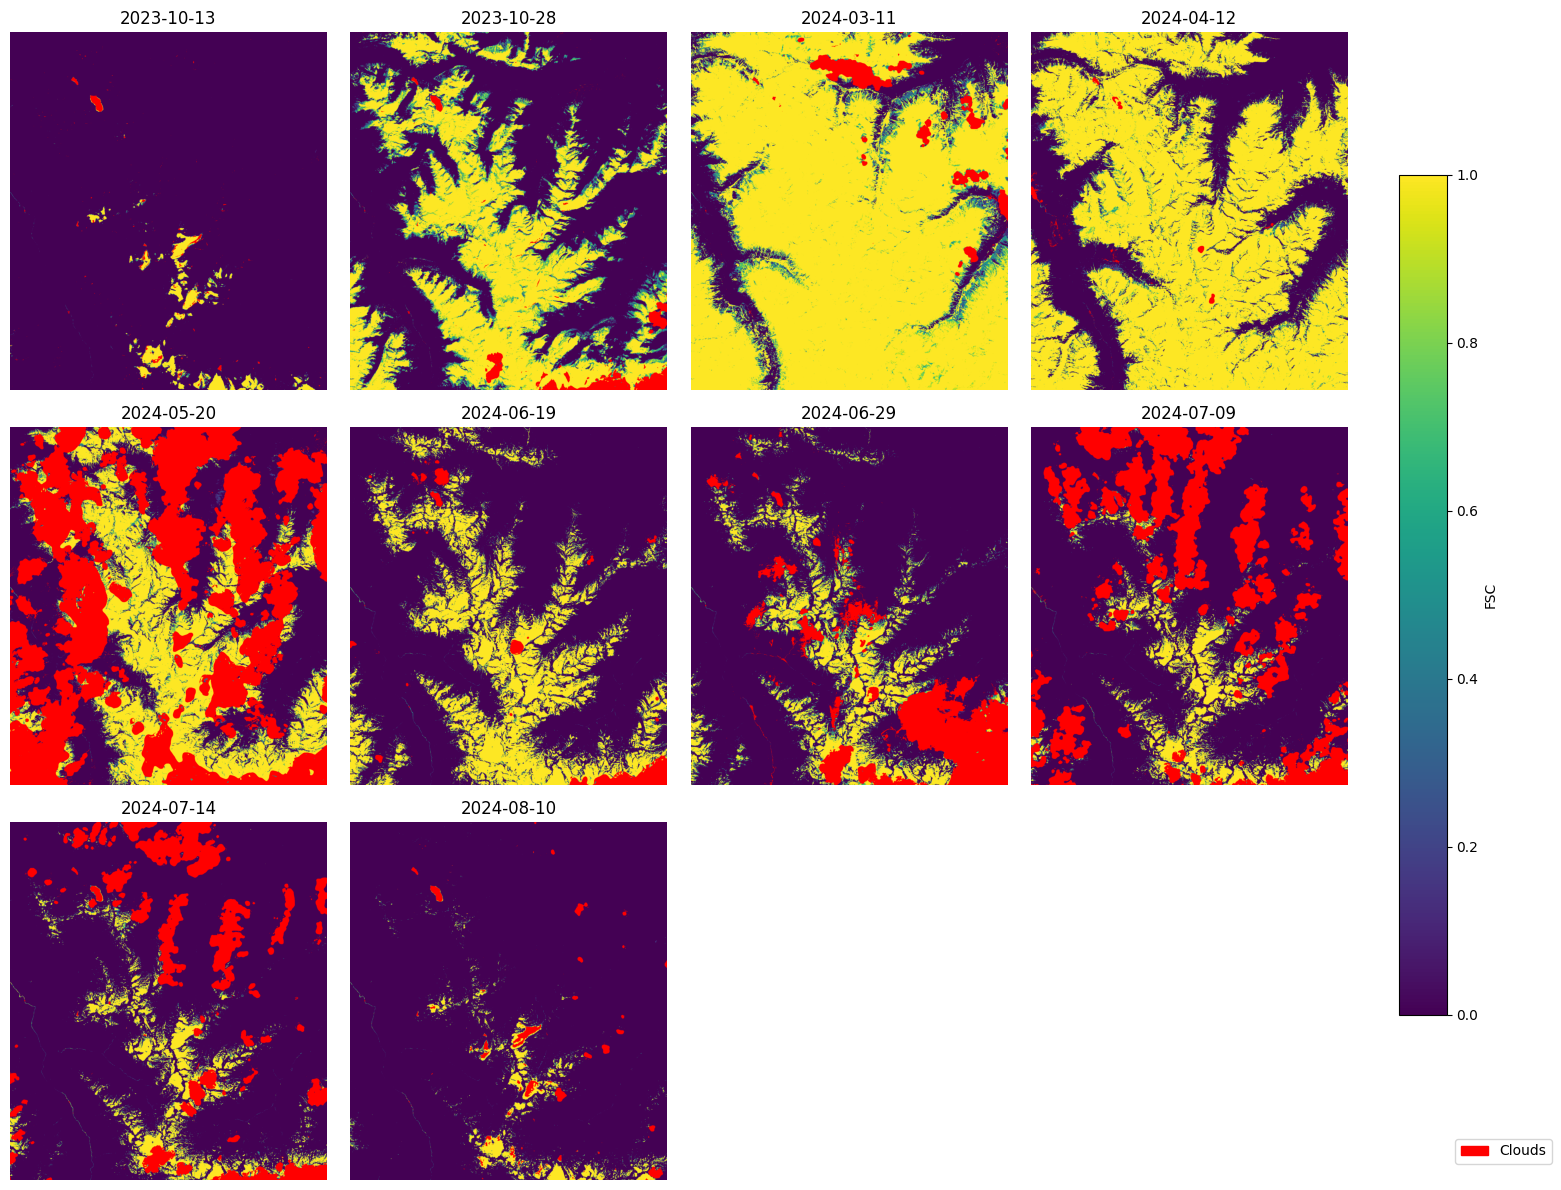

In [74]:
# Plot only the selected images from the "selected" directory

selected_pattern = re.compile(r"ndsi_(\d{4}-\d{2}-\d{2})\.tiff")
selected_datasets = []

for file in os.listdir(selected_dir):
    match = selected_pattern.match(file)
    if match:
        date_str = match.group(1)
        date = pd.to_datetime(date_str).date()
        file_path = os.path.join(selected_dir, file)
        ds = rxr.open_rasterio(file_path)
        if "time" not in ds.dims:
            ds = ds.expand_dims(time=[pd.Timestamp(date)])
        selected_datasets.append(ds)

if selected_datasets:
    selected_combined = xr.concat(selected_datasets, dim="time")
    selected_combined.rio.write_nodata(np.nan, inplace=True)
else:
    print("No selected NDSI TIFF files found.")

n_selected = len(selected_combined.time)
nrows_sel = 3
ncols_sel = int(np.ceil(n_selected / nrows_sel))

cmap_sel = cm.get_cmap("viridis").copy()
cmap_sel.set_bad(color="red")

fig_sel, axes_sel = plt.subplots(nrows=nrows_sel, ncols=ncols_sel, figsize=(4*ncols_sel, 4*nrows_sel))
axes_sel = axes_sel.flatten()

for i in range(n_selected):
    ax = axes_sel[i]
    img = np.ma.masked_invalid(selected_combined[i, 0, :, :])
    im = ax.imshow(img, vmin=0, vmax=1, cmap=cmap_sel)
    ax.set_title(f"{str(selected_combined.time.values[i])[:10]}")
    ax.axis("off")

for j in range(n_selected, len(axes_sel)):
    axes_sel[j].axis("off")

fig_sel.subplots_adjust(right=0.85)
cbar_ax_sel = fig_sel.add_axes([0.88, 0.15, 0.03, 0.7])
fig_sel.colorbar(im, cax=cbar_ax_sel, label="FSC")

red_patch_sel = mpatches.Patch(color='red', label='Clouds')
fig_sel.legend(handles=[red_patch_sel], loc='lower right', bbox_to_anchor=(0.98, 0.02))

plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()